In [129]:
from dotenv import load_dotenv

load_dotenv()

True

In [130]:
# from langchain_community.document_loaders import Docx2txtLoader
# from langchain_text_splitters import RecursiveCharacterTextSplitter
# from langchain_community.document_loaders import UnstructuredMarkdownLoader


# splitter = RecursiveCharacterTextSplitter(
#   chunk_size= 2000,
#   chunk_overlap= 500
# )

# loader = UnstructuredMarkdownLoader('documents/real_estate_tax.md')


# document_list  = loader.load_and_split(text_splitter= splitter)

# document_list

In [ ]:
# from langchain_chroma import Chroma
# from langchain_upstage import UpstageEmbeddings

# embedding = UpstageEmbeddings(model = 'solar-embedding-1-large')

# 처음 DB 생성할 때는 이 방식으로

# database = Chroma.from_documents(
#   documents= document_list,
#   embedding=embedding, 
#   collection_name='real_estate_tax',
#   persist_directory= './real_estate_tax_collection'
# )

In [133]:
from langchain_upstage import UpstageEmbeddings
from langchain_chroma import Chroma
from langchain_anthropic import ChatAnthropic
from langsmith import Client

embedding = UpstageEmbeddings(model="solar-embedding-1-large")

database = Chroma(
    embedding_function = embedding,
    collection_name = 'real_estate_tax',
    persist_directory = './real_estate_tax_collection'
)
retriever = database.as_retriever(
    search_type= 'mmr',
    search_kwargs={
        'k': 4,
        'fetch_k': 10,
        'lambda_mult': 0.6
    }
)

client = Client()

# 비용의 80%는 Haiku가, 정확도의 80%는 Sonnet/Opus가!!

smart_llm = ChatAnthropic(
    model= 'claude-opus-4-5-20251101',
    temperature= 0.1
)

llm = ChatAnthropic(
    model= 'claude-sonnet-4-5-20250929',
    temperature= 0.1
)

small_llm = ChatAnthropic(
    model= 'claude-haiku-4-5-20251001',
    temperature= 0.1
)

In [134]:
from typing_extensions import List, TypedDict
from langchain_core.documents import Document


class AgentState(TypedDict):
    query: str # 사용자 질문
    answer: str # 세율
    tax_base_equation: str # 과세표준 계산 수식 
    tax_deduction: str # 공제액 
    market_ratio: str # 공정시장가액비율
    tax_base: str # 과세표준 계산
    

generate_prompt = client.pull_prompt("rlm/rag-prompt")

In [135]:
query = '5억짜리 집 1채, 10억짜리 집 1채, 20억짜리 집 1채를 가지고 있을 때 세금을 얼마나 내나요?'

## 병렬 구조 1. 과표 계산 수식만 return

In [152]:
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from typing import Literal
from langchain_core.runnables import RunnablePassthrough
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnableLambda

tax_base_retrieval_chain = (
    {'context': retriever, 'question': RunnablePassthrough()} 
    | generate_prompt 
    | small_llm 
    | StrOutputParser()
)

tax_base_equation_prompt = ChatPromptTemplate.from_messages([
    ('system', '사용자의 질문에서 과세표준을 계산하는 방법을 수식으로 나타내주세요. 부연설명 없이 수식만 리턴해주세요'),
    ('human', '{tax_base_equation_information}')
])

tax_base_equation_chain = (
    {'tax_base_equation_information': RunnablePassthrough()}
    | tax_base_equation_prompt
    | small_llm
    | StrOutputParser()
)

tax_base_chain = {'tax_base_equation_information' : tax_base_retrieval_chain} | tax_base_equation_chain

def get_tax_base_equation(state: AgentState) -> AgentState:
    """
    종합부동산세 과세표준을 계산하는 수식을 가져옵니다.
    `node`로 활용되기 때문에 `state`를 인자로 받지만, 
    고정된 기능을 수행하기 때문에 `state`를 활용하지는 않습니다.

    Args:
        state (AgentState): 현재 에이전트의 상태를 나타내는 객체입니다.

    Returns:
        AgentState: 'tax_base_equation' 키를 포함하는 새로운 `state`를 반환합니다.
    """
    # 과세표준을 계산하는 방법을 묻는 질문을 정의합니다.
    tax_base_equation_question = '주택에 대한 종합부동산세 계산시 과세표준을 계산하는 방법을 수식으로 표현해서 알려주세요'
    
    # tax_base_chain을 사용하여 질문을 실행하고 결과를 얻습니다.
    tax_base_equation = tax_base_chain.invoke(tax_base_equation_question)
    
    # state에서 'tax_base_equation' 키에 대한 값을 반환합니다.
    return {'tax_base_equation': tax_base_equation}

In [137]:
# get_tax_base_equation({})

## 병렬구조 2. 공제액 계산

In [153]:
from langchain_core.runnables import RunnableLambda


tax_deduction_chain = (
    {
        'context': RunnableLambda(lambda x: x['search_query']) | retriever,
        'question': RunnableLambda(lambda x: x['full_prompt']) 
    } 
    | generate_prompt 
    | small_llm 
    | StrOutputParser()
)

def get_tax_deduction(state: AgentState) -> AgentState:
    """
    종합부동산세 공제금액에 관한 정보를 가져옵니다.
    `node`로 활용되기 때문에 `state`를 인자로 받지만, 
    고정된 기능을 수행하기 때문에 `state`를 활용하지는 않습니다.

    Args:
        state (AgentState): 현재 에이전트의 state를 나타내는 객체입니다.

    Returns:
        AgentState: 'tax_deduction' 키를 포함하는 새로운 state를 반환합니다.
    """
    # 공제금액을 묻는 질문을 정의합니다.
    tax_deduction_question ={
    'search_query': '납세의무자 유형별 종합부동산세 공제금액',
    'full_prompt': '종합부동산세 공제금액을 납세의무자 유형별로 정리하세요. 반드시 다음 형식으로...'
}
    
    # tax_deduction_chain을 사용하여 질문을 실행하고 결과를 얻습니다.
    tax_deduction = tax_deduction_chain.invoke(tax_deduction_question)

    # state에서 'tax_deduction' 키에 대한 값을 반환합니다.
    return {'tax_deduction': tax_deduction}

In [ ]:
# get_tax_deduction({})

{'tax_deduction': '제공된 context에서 종합부동산세 공제금액을 납세의무자 유형별로 정리하면 다음과 같습니다:\n\n- 1세대 1주택자: 확인 불가\n- 그 외(다주택자): 확인 불가\n- 법인: 확인 불가\n\nContext에는 구체적인 공제금액(억원 단위)이 명시되어 있지 않으며, 공제율(%)과 공제 계산 방식만 규정되어 있습니다.'}

## 병렬구조3. 공정시장가액비율 가져오기

In [140]:
from langchain_community.tools import TavilySearchResults
from datetime import date

tavily_search_tool = TavilySearchResults(
    max_results=7,
    search_depth='advanced',
    include_answer=True,
    include_raw_content=True,
    include_images=False
    # include_domains=
    # exclude_domains=
    # name=
    # description=
    # args_schema=
)

tax_market_ratio_prompt = ChatPromptTemplate.from_messages([
    ('system', f'아래 정보를 기반으로 공정시장 가액비율을 계산해주세요\n\nContext:\n{{context}}'),
    ('human', '{query}')
])

def get_market_ratio(state: AgentState) -> AgentState:
    """
    web 검색을 통해 주택 공시가격에 대한 공정시장가액비율을 가져옵니다.
    `node`로 활용되기 때문에 `state`를 인자로 받지만, 
    고정된 기능을 수행하기 때문에 `state`를 활용하지는 않습니다.
    
    Args:
        state (AgentState): 현재 에이전트의 state를 나타내는 객체입니다.

    Returns:
        AgentState: 'market_ratio' 키를 포함하는 새로운 state를 반환합니다.
    """
    # 오늘 날짜에 해당하는 공정시장가액비율을 묻는 쿼리를 정의합니다.
    query = f'오늘 날짜:({date.today()})에 해당하는 주택 공시가격 공정시장가액비율은 몇%인가요?'
    
    # tavily_search_tool을 사용하여 쿼리를 실행하고 컨텍스트를 얻습니다.
    context = tavily_search_tool.invoke(query)
    
    # tax_market_ratio_chain을 구성하여 쿼리와 컨텍스트를 처리합니다.
    tax_market_ratio_chain = (
        tax_market_ratio_prompt
        | small_llm
        | StrOutputParser()
    )
    
    # tax_market_ratio_chain을 사용하여 시장 비율을 계산합니다.
    market_ratio = tax_market_ratio_chain.invoke({'context': context, 'query': query})
    
    # state에서 'market_ratio' 키에 대한 값을 반환합니다.
    return {'market_ratio': market_ratio}

In [141]:
# get_market_ratio({})

## 병렬 Node들을 합치는 Node

In [142]:
from langchain_core.prompts import PromptTemplate

tax_base_calculate_prompt = ChatPromptTemplate.from_messages(
    [
        ('system', """
당신의 역할은 종합부동산세 **과세표준만** 계산하는 것입니다.
세율 적용, 세액 계산은 절대 하지 마세요.
제공되지 않은 정보는 절대 추측하지 마세요.

## 과세표준 계산 공식
{tax_base_equation}

## 공제금액 (반드시 아래 값을 사용할 것)
{tax_deduction}

## 공정시장가액비율 (반드시 아래 값을 사용할 것)
{market_ratio}

## 출력 형식
1. 납세의무자 유형 판단
2. 적용할 공제금액과 공정시장가액비율 명시
3. 과세표준 계산 과정
4. 최종 과세표준 금액

과세표준 계산까지만 하고 멈추세요."""),
        ('human', '사용자 주택 공시가격 정보: {query}')
    ]
)

def calculate_tax_base(state: AgentState)-> dict[str, str]:
    tax_base_equation = state['tax_base_equation']
    tax_deduction = state['tax_deduction']
    market_ratio = state['market_ratio']
    query = state['query']
    
    tax_base_calculate_chain = (
        tax_base_calculate_prompt
        | llm
        | StrOutputParser()
    )
    
    tax_base = tax_base_calculate_chain.invoke({
        'tax_base_equation': tax_base_equation,
        'tax_deduction': tax_deduction,
        'market_ratio': market_ratio,
        'query': query
    })

    
    return {'tax_base': tax_base}

In [ ]:
# test_state = {
#     'query': '5억짜리 집 1채, 10억짜리 집 1채, 20억짜리 집 1채를 가지고 있을 때 세금을 얼마나 내나요?',
#     'tax_base_equation': '과세표준 = max(0, (주택의 공시가격 합계 - 공제금액) × 공정시장가액비율)',
#     'tax_deduction': '종합부동산세 과세표준 공제금액은 납세의무자 유형별로 다음과 같습니다:\n\n- 1세대 1주택자: 12억원\n- 그 외(다주택자): 9억원\n- 법인: 6억원',
#     'market_ratio': '다주택자: 60%\n법인: 60%\n1세대 1주택자: 공시가격별 43~45%',
#     'tax_base': '',
#     'answer': ''
# }

# test_state['tax_base'] = calculate_tax_base(test_state)

In [144]:
tax_calculate_prompt = ChatPromptTemplate.from_messages([
    ('system', """당신의 역할은 종합부동산세 **세액만** 계산하는 것입니다.
제공된 과세표준과 세율표만 사용하세요.
제공되지 않은 정보는 절대 추측하지 마세요.
절세 팁, 추가 조언 등은 작성하지 마세요.

## 세율표 (반드시 아래 세율만 사용할 것)
{context}

## 출력 형식
1. 납세의무자 유형 확인 (주택 수 기준)
2. 적용할 세율표 선택
3. 과세표준 구간별 누진 계산 과정
4. 최종 종합부동산세 산출세액

세액 계산까지만 하고 멈추세요."""),
    ('human', """과세표준과 사용자가 소지한 주택의 수가 아래와 같을 때 종합부동산세를 계산해 주세요.

과세표준: {tax_base}
주택 수: {query}""")
])

tax_calculate_chain = (
    tax_calculate_prompt
    | llm
    | StrOutputParser()
)

def calculate_tax(state: AgentState) -> dict[str, str]:
    query = state['query']
    tax_base = state['tax_base']
    context = retriever.invoke('종합부동산세 제9조 주택 세율표 2주택 3주택')

    tax = tax_calculate_chain.invoke({
        'query': query,
        'tax_base': tax_base,
        'context': context
    })
    
    return {'answer': tax}

## Build 시작

In [145]:
from langgraph.graph import StateGraph, START, END

graph_builder = StateGraph(AgentState)


graph_builder.add_node('get_tax_base_equation', get_tax_base_equation)
graph_builder.add_node('get_tax_deduction', get_tax_deduction)
graph_builder.add_node('get_market_ratio', get_market_ratio)
graph_builder.add_node('calculate_tax_base', calculate_tax_base)
graph_builder.add_node('calculate_tax', calculate_tax)


graph_builder.add_edge(START, 'get_tax_base_equation')
graph_builder.add_edge(START, 'get_tax_deduction')
graph_builder.add_edge(START, 'get_market_ratio')

graph_builder.add_edge('get_tax_base_equation', 'calculate_tax_base')
graph_builder.add_edge('get_tax_deduction', 'calculate_tax_base')
graph_builder.add_edge('get_market_ratio', 'calculate_tax_base')


graph_builder.add_edge('calculate_tax_base', 'calculate_tax')
graph_builder.add_edge('calculate_tax', END)


graph = graph_builder.compile()

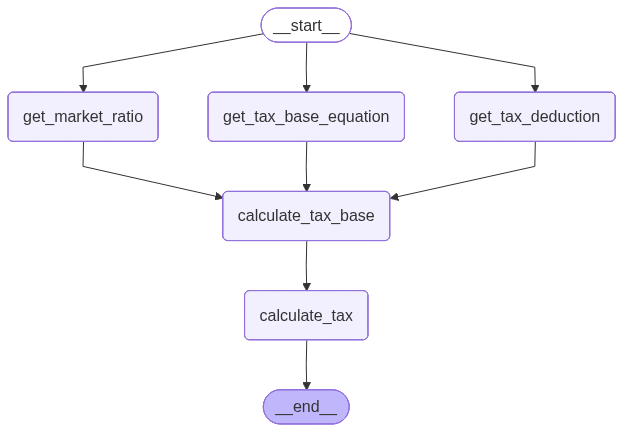

In [146]:
from IPython.display import display, Image

display(Image(graph.get_graph(xray=False).draw_mermaid_png()))

In [ ]:
query = '5억짜리 집 1채, 10억짜리 집 1채, 20억짜리 집 1채를 가지고 있을 때 세금을 얼마나 내나요?'
initial_state = {'query': query}
response = graph.invoke(initial_state)

In [ ]:
display(Markdown(response['answer']))

In [149]:
## 하고 싶은 것 ##

# System prompt 경량화 - 법률 전문을 넣지 말고, retrieve된 관련 조문만
# Context 재사용 - 병렬 노드들이 같은 문서를 각각 retrieve하지 않도록

# 오늘 배운 병렬 기법으로 주요 기능들을 module화 해서 
# 다른 Agent가 호출할 수 있는 Tool로 만드는 것!

# 작은 모델로 대체할 수 있는 작업은 작은 모델로 대체하기!

# 종합부동산세 RAG 파이프라인 최적화 리포트

## 테스트 쿼리
> "5억짜리 집 1채, 10억짜리 집 1채, 20억짜리 집 1채를 가지고 있을 때 세금을 얼마나 내나요?"

---

## Before vs After

| 항목 | Before (01/31) | After (02/02) | 변화 |
|------|---------------|---------------|------|
| **비용** | $0.237 | $0.081 | **-66%** |
| **토큰** | 37,112 | 35,027 | -6% |
| **정답 여부** |  1,680만원 |  1,680만원 | 동일 |
| **환각** | 없음 (Opus가 알아서 처리) | 없음 (프롬프트로 통제) | 동일 |

---

## 변경 사항 상세

### 1. 모델 분리 (역할별 모델 배정)

**Before:** 전 노드 Opus 4.5 ($15/1M input)

**After:**

| 노드 | 역할 | 모델 | 이유 |
|------|------|------|------|
| `get_tax_base_equation` | retrieve + 정리 | **Haiku** | 단순 검색/정리 작업 |
| `get_tax_deduction` | retrieve + 정리 | **Haiku** | 단순 검색/정리 작업 |
| `get_market_ratio` | 웹검색 + 정리 | **Haiku** | 단순 검색/정리 작업 |
| `calculate_tax_base` | 과세표준 계산 | **Sonnet** | 다단계 추론 필요 |
| `calculate_tax` | 세액 계산 | **Sonnet** | 다단계 추론 필요 |

**효과:** 비용 66% 절감 ($0.237 → $0.081)

---

### 2. Retrieve 쿼리 구체화

**Before:**
```python
tax_deduction_question = '주택에 대한 종합부동산세 계산시 공제금액을 알려주세요'
```

→ 결과: "그 외의 경우 공제금액이 다르게 적용됩니다" (구체적 금액 없음)
→ Sonnet이 6억으로 추측 X

**After:**
```python
tax_deduction_question = '종합부동산세 1세대 1주택자 공제금액 12억 9억 6억 납세의무자 유형별'
```

→ 결과: "1세대 1주택자: 12억원 / 다주택자: 9억원 / 법인: 6억원" 

**효과:** 공제금액 9억원 정확히 retrieve

---

### 3. 프롬프트 제약 추가

#### 3-1. calculate_tax_base 프롬프트

**Before:**
```
주어진 내용을 기반으로 과세표준을 계산해주세요
```

→ Sonnet이 세율표까지 환각으로 생성, 세액까지 계산 (역할 침범)

**After:**
```
당신의 역할은 종합부동산세 **과세표준만** 계산하는 것입니다.
세율 적용, 세액 계산은 절대 하지 마세요.
제공되지 않은 정보는 절대 추측하지 마세요.
...
과세표준 계산까지만 하고 멈추세요.
```

**효과:** 과세표준만 정확히 계산하고 멈춤

#### 3-2. calculate_tax 프롬프트

**Before:**
```
종합부동산세를 계산해주세요
```

→ 절세 팁 환각 생성 ("공제액 증가 12억 → 9억" - 방향 반대로 틀림)

**After:**
```
당신의 역할은 종합부동산세 **세액만** 계산하는 것입니다.
제공된 과세표준과 세율표만 사용하세요.
제공되지 않은 정보는 절대 추측하지 마세요.
절세 팁, 추가 조언 등은 작성하지 마세요.
...
세액 계산까지만 하고 멈추세요.
```

**효과:** 세율표 정확 적용, 환각 없음

---

## 핵심 교훈

### 프롬프트 엔지니어링 3원칙

| 원칙 | 적용 | 효과 |
|------|------|------|
| **역할 범위 제한** | "과세표준**만** 계산", "세액**만** 계산" | 노드 간 역할 침범 방지 |
| **Context 사용 강제** | "반드시 아래 값을 사용할 것" | 모델이 입력값 무시하는 것 방지 |
| **환각 방지** | "제공되지 않은 정보는 추측 금지" | 존재하지 않는 세율표 생성 방지 |

### 모델 선택 vs 프롬프트

- k를 높이는 것 = "재료를 잔뜩 쏟아붓기" → 비용↑ 노이즈↑
- 좋은 모델에 의존 = "비싼 셰프한테 무책임하게 맡기기" → 비용↑ 통제 불가
- **프롬프트 제약 = "정확한 재료 + 명확한 레시피"** → 비용↓ 정확도↑

### Haiku의 한계

Haiku는 retrieve/분류/정리에는 충분하지만, 다단계 계산에서는 환각이 심함.
(공제금액 0원, 세율표 완전 조작 등의 사례 확인됨)
→ 역할별 모델 분리가 필수

---

## 추가 최적화 여지

| 항목 | 현재 | 개선 시 기대 효과 |
|------|------|------------------|
| System prompt 경량화 | 법률 전문 포함 | 토큰 30-50% 추가 절감 |
| Prompt Caching | 미적용 | 반복 호출 시 90% 할인 |
| Retriever k 추가 조정 | k=4 | 노이즈 감소 |
| Reranker 도입 | 미적용 | retrieve 정확도 향상 |